In [2]:
import duckdb as duckdb
from dotenv import load_dotenv
import os

load_dotenv()

True

In [3]:
db_path = os.getenv("DB_PATH")
data_path = os.getenv("DATA_PATH")

In [21]:
query = f"""
select SUM(agg_valor) as agg_valor, AVG(temperatura) as temperatura
        from (
            select departamento, dia, hora, SUM(valor) as agg_valor
            from read_parquet('{data_path}')
            group by departamento, dia, hora
        ) e inner join temp_departamento t on e.dia=t.dia and e.hora=t.hora and t.departamento = e.departamento
        group by e.dia
        order by e.dia
"""

con = duckdb.connect(database= db_path)
result = con.query(query).to_df()


In [22]:
result.head()

,agg_valor,temperatura
0,1.145678e+06,16.106242
1,1.076196e+06,17.609121
2,1.094952e+06,15.106273
3,1.186305e+06,10.549375
4,1.258924e+06,11.068918


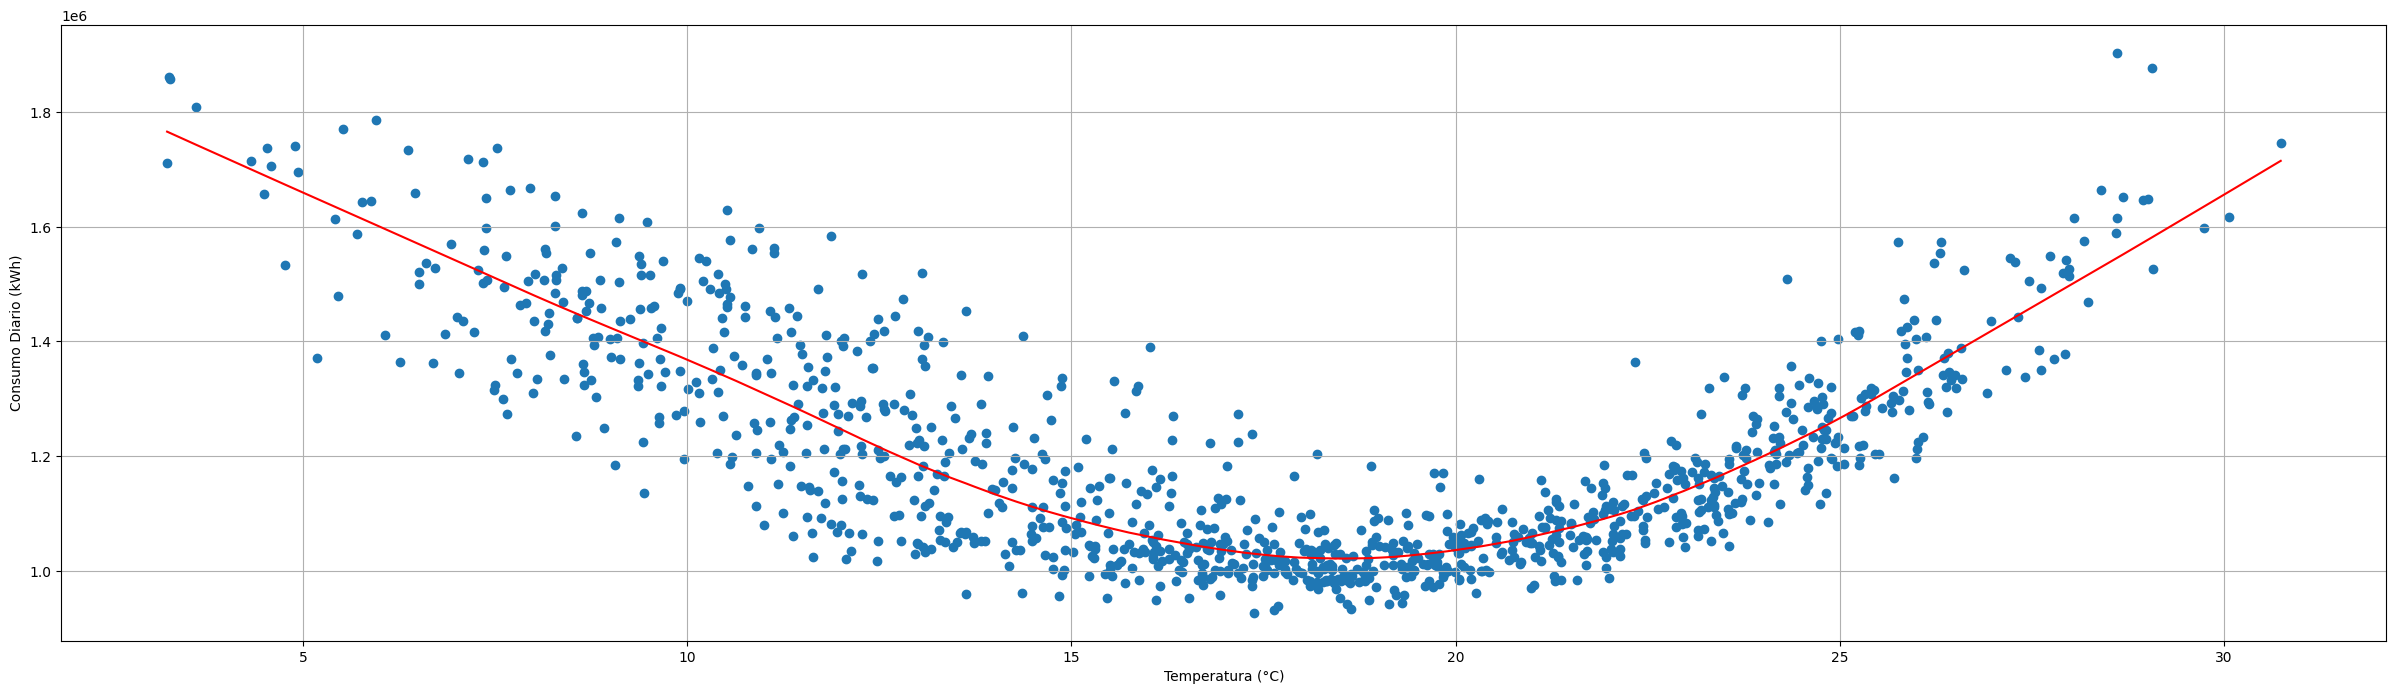

In [24]:
#print all the results, temp_int en x-axis y consumo promedio en y-axis
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 8))
plt.scatter(result['temperatura'], result['agg_valor'])

#Compute lowess curve
from statsmodels.nonparametric.smoothers_lowess import lowess
lowess_result = lowess(result['agg_valor'], result['temperatura'], frac=0.3)
plt.plot(lowess_result[:, 0], lowess_result[:, 1], color='red', label='Lowess Curve')

plt.xlabel('Temperatura (°C)')
plt.ylabel('Consumo Diario (kWh)')
plt.grid()
plt.show()